# Optimizing Functions of One Variable: Cost Minimization

In this assignment you will solve a simple optimization problem for a function of one variable. Given a dataset of historical prices of a product from two suppliers, your task is to identify what share of the product you should buy from each of the suppliers to make the best possible investment in the future. Stating the problem mathematically, you will construct a target function to minimize, evaluate its minimum and investigate how its derivative is connected with the result.

- **investigate** /ɪnˈvestɪɡeɪt/ 研究；调查：意思是**研究「导数与最优解之间的关系」**，也就是探究「为什么最小值点对应导数为 0」。
- **investment** /ɪnˈvestmənt/ 投资：指的是**投资组合管理问题**。在这个 Lab 里，你决定从供应商 A 和 B 各采购多少比例，本质上是「把预算投资到两个供应商」，目标是让成本波动最小，这和金融里的「最小方差投资组合」是同一类问题。

## 背景知识

### 预测与成本稳定的区别

一、先回顾「square loss」的标准形式

**回归问题**：

$$
L(w) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

- $y_i$: 真实值
- $\hat{y}_i$: 预测值
- $(y_i - \hat{y}_i)$: 误差
- 目标：让误差平方和最小

**这是「预测 vs 真实」的差距。**

---

**二、Lab 里的损失函数**

$$
\mathcal{L}(\omega) = \frac{1}{k} \sum_{i=1}^{k} \left( f^i(\omega) - \overline{f(\omega)} \right)^2
$$

- $f^i(\omega)$: 第 i 个月的成本
- $\overline{f(\omega)}$: 所有月份成本的平均值
- $\left( f^i(\omega) - \overline{f(\omega)} \right)$: 每个月的成本偏离平均值的程度
- 目标：让偏离平方的平均值最小

**这是「每个值 vs 平均值」的差距。**



---


**三、两者本质区别**

| 维度 | Square Loss | Lab 里的损失 |
|---|---|---|
| **比较对象** | 预测值 vs 真实值 | 每个月的成本 vs 平均值 |
| **目标** | 预测越准越好 | 成本波动越小越好 |
| **统计含义** | 最小化误差 | 最小化方差 |
| **优化对象** | 模型参数 | 采购比例 $\omega$ |
| **预测未来？** | 是 | 不直接预测 |


### 成本稳定


**一、先看「不稳定」是什么样**

假设你每月采购 1000 件产品，有两种采购策略：

> 策略 A：全从供应商 A 采购

| 月份 | A 的价格 | 你的成本 |
| ---- | -------- | -------- |
| 1 月 | 100      | 100,000  |
| 2 月 | 80       | 80,000   |
| 3 月 | 120      | 120,000  |
| 4 月 | 90       | 90,000   |
| 5 月 | 110      | 110,000  |

**成本在 80,000 到 120,000 之间大幅波动。**

> 策略 B：从 A 采购 70%，从 B 采购 30%

| 月份 | A 价格 | B 价格 | 你的成本                            |
| ---- | ------ | ------ | ----------------------------------- |
| 1 月 | 100    | 95     | 0.7×100 + 0.3×95 = 98.5 → 98,500    |
| 2 月 | 80     | 90     | 0.7×80 + 0.3×90 = 83 → 83,000       |
| 3 月 | 120    | 100    | 0.7×120 + 0.3×100 = 114 → 114,000   |
| 4 月 | 90     | 85     | 0.7×90 + 0.3×85 = 88.5 → 88,500     |
| 5 月 | 110    | 105    | 0.7×110 + 0.3×105 = 108.5 → 108,500 |

**成本仍然在波动，但幅度可能小一些。**

---

#### 二、「稳定」的含义

**稳定 = 成本变化小。**

用数学语言：

> **每个月的成本，都接近「平均成本」。**

**不稳定的例子**：

```
平均成本 = 100,000

月份成本：80,000, 120,000, 90,000, 110,000
偏离：    -20,000, +20,000, -10,000, +10,000
```

**偏离很大 → 不稳定。**

**稳定的例子**：

```
平均成本 = 100,000

月份成本：98,000, 102,000, 99,000, 101,000
偏离：    -2,000, +2,000, -1,000, +1,000
```

**偏离很小 → 稳定。**

---

###### 三、为什么「稳定」重要

**1. 预算可控**

如果成本稳定：

- 你知道每个月大概花 100,000
- 预算容易做
- 现金流容易管理

如果成本不稳定：

- 有的月份花 80,000
- 有的月份花 120,000
- 预算很难做
- 可能某个月现金不够

**2. 风险小**

**波动 = 风险。**

- 波动大 → 你不知道下个月要花多少 → 风险大
- 波动小 → 你能预测下个月的成本 → 风险小

**3. 谈判有利**

和供应商谈判时：

- 你能说：「我要的是稳定供应，不是最低价」
- 这给你更多谈判筹码

---

## Lab 的目标

**不是**：

> 让平均成本最低。

**而是**：

> 让成本波动最小。

**为什么？**

- 平均成本最低可能意味着某个月极高、某个月极低
- 波动最小意味着每个月都差不多，**预算可控**

**投资组合理论**：

> **不追求收益最高，追求风险最小。**

---

**数学表达**

**稳定 = 方差小。**

$$
\mathcal{L}(\omega) = \frac{1}{k} \sum_{i=1}^{k} \left( f^i(\omega) - \overline{f(\omega)} \right)^2
$$

- 每个月的成本 $f^i(\omega)$
- 平均成本 $\overline{f(\omega)}$
- 偏离越小 → $\mathcal{L}$ 越小 → 越稳定
---

> 用一个类比

**你是一个公司的财务主管。**

**方案 A**：

- 每月花 100,000（不变）
- 预算很好做

**方案 B**：

- 有的月花 50,000
- 有的月花 150,000
- 平均也是 100,000
- 但预算很难做

**你选哪个？**

**财务上，通常选 A（稳定）。**

**这就是「让成本稳定」的含义。**

---

一句话总结

> **「让成本稳定」= 让每个月的成本都接近平均值，不要忽高忽低。这样预算可控、风险小、谈判有利。数学上，就是最小化方差。**


# Table of Contents

- [ 1 - Statement of the Optimization Problem](#1)
  - [ 1.1 - Description of the Problem](#1.1)
  - [ 1.2 - Mathematical Statement of the Problem](#1.2)
  - [ 1.3 - Solution Approach](#1.3)
- [ 2 - Optimizing Function of One Variable in Python](#2)
  - [ 2.1 - Packages](#2.1)
  - [ 2.2 - Open and Analyze the Dataset](#2.2)
    - [ Exercise 1](#ex01)
  - [ 2.3 - Construct the Function $\mathcal{L}$ to Optimize and Find its Minimum Point](#2.3)
    - [ Exercise 2](#ex02)
    - [ Exercise 3](#ex03)
    - [ Exercise 4](#ex04)

<a name='1'></a>

## 1 - Statement of the Optimization Problem

<a name='1.1'></a>

### 1.1 - Description of the Problem

Your Company is aiming to minimize production costs(生产成本) of some goods. During the production process, an `essential` product P is used, which can be supplied from one of two partners - supplier A and supplier B. Your `consultants` requested the historical prices of product P from both suppliers A and B, which were provided as **monthly averages** for the period from February 2018 to March 2020. (monthly average（月度平均值）= 把一个月内每一天的价格加起来，再除以这个月的天数。)

Preparing Company Budget for the coming twelve months period, your plan is to purchase the same amount of product P monthly. Choosing the supplier, you noticed, that there were some periods in the past, when it would be more `profitable` to use supplier A (the prices of product P were lower), and other periods to work with supplier B. For the Budget model you can set some percentage of the goods to be purchased from supplier A (e.g. 60%) and the remaining part from supplier B (e.g. 40%), but this `split` should be kept consistent for the whole of the twelve months period. The Budget will be used in preparation for the contract negotiations with both suppliers.

Based on the historical prices, is there a particular percentage which will be more profitable to supply from Company A, and the remaining part from Company B? Or maybe it does not matter and you can work just with one of the suppliers?


在预算模型里，你可以设定从供应商 A 采购的百分比（比如 60%），剩余的从供应商 B 采购（比如 40%），**但这个比例必须在整个 12 个月期间保持一致**。

有约束

- 你不能这个月 70% 从 A，下个月 30% 从 A
- **一旦确定了 ω，就 12 个月都用它**

如果没有这个约束

- 每个月都重新优化 ω
- 需要预测未来每个月的价格
- **这是「动态优化」问题，复杂得多**


---

- essential /ɪˈsenʃl/ 必不可少的；必需的；本质的
- consultants /kənˈsʌltənts/ 顾问（复数）
- profitable /ˈprɒfɪtəbl/ 有利可图的；能赚钱的
- split /splɪt/ 分配比例
- contract /ˈkɒntrækt/ 合同
- negotiations /nɪˌɡəʊʃiˈeɪʃnz/ 谈判

<a name='1.2'></a>

### 1.2 - Mathematical Statement of the Problem

Denoting prices of the product P from Company A and Company B as $p_A$ (USD) and $p_B$ (USD) respectively, and the volume of the product to be supplied per month as $n$ (units), the total cost in USD is:

$$f\left(\omega\right) = p_A \omega \,n+ p_B \left(1 - \omega\right) n,$$

where $0\leq\omega\leq1$ is the parameter. If $\omega = 1$, all goods will be supplied from Company A, and if $\omega = 0$, from Company B. In case of $0<\omega<1$, some percentage will be allocated to both. 

As it is planned to keep the volume $n$ constant over the next twelve months, in the mathematical model the common approach is to put $n = 1$. You can do this, because nothing depends on the volume and the end result will be the same. Now the total cost will be simpler:

$$f\left(\omega\right) = p_A \omega+ p_B \left(1 - \omega\right) \tag{1}$$

Obviously, you do not know the future prices $p_A$ and $p_B$, only historical values (prices $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$ for $k$ months). And historically there were various periods of time when it was better to take $\omega = 1$ ($p_A^i < p_B^i$) or $\omega = 0$ ($p_A^i >p_B^i$). Is it possible now to choose some $\omega$ value that would provide some evidence of minimum costs in the future?

- evidence /ˈevɪdəns/ 依据

<a name='1.3'></a>
### 1.3 - Solution Approach

This is a standard **portfolio management** (investment) problem well known in statistics, where based on the historical prices you need to make investment decision to maximize profit (minimize costs). Since statistics has not been covered in this Course, you do not need to understand the details about the function $\mathcal{L}\left(\omega\right)$ (called **loss function**) to minimize, explained in the next paragraph.

The approach is to calculate $f\left(\omega\right)$ for each of the historical prices $p_A^i$ and $p_B^i$, $f^i\left(\omega\right)=p_A^i \omega+ p_B^i \left(1 - \omega\right)$. Then take an average of those values, $\overline{f\left (\omega\right)}=\text{mean}\left(f^i\left(\omega\right)\right) = \frac{1}{k}\sum_{i=1}^{k}f^i\left(\omega\right)$ and look for such value of $\omega$ which makes $f^i\left(\omega\right)$ as "stable" as possible - varying as little as possible from the average $\overline{f\left (\omega\right)}$. This means that you would want to minimize the sum of the differences $\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)$. As the differences can be negative or positive, a common approach is to take the squares of those and take an average of the squares:

$$\mathcal{L}\left(\omega\right) = \frac{1}{k}\sum_{i=1}^{k}\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)^2\tag{2}$$

In statistics $\mathcal{L}\left(\omega\right)$ is called a variance of $\{f^1 \left(\omega\right), \cdots , f^k \left(\omega\right)\}$. The aim is to minimize the variance $\mathcal{L}\left(\omega\right)$, where $\omega\in\left[0, 1\right]$. Again, do not worry if you do not understand deeply why particularly this function $\mathcal{L}\left(\omega\right)$ was chosen. You might think if it is logical to minimize an average $\overline{f\left (\omega\right)}$, but [risk management](https://www.thebalancemoney.com/minimum-variance-portfolio-overview-4155796#:~:text=A%20minimum%20variance%20portfolio%20is,other%20out%20when%20held%20together.) theory states that in this problem variance needs to be optimized.

Statistical theory shows that there is an $\omega\in\left[0, 1\right]$ value which minimizes function $\mathcal{L}\left(\omega\right)$ and it can be found using some properties of the datasets $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$. However, as this is not a Course about statistics, the example is taken to illustrate an optimization problem of one variable based on some dataset. It is a chance for you to check your understanding and practice this week material. 

Now let's upload a dataset and explore if it is possible to find a minimum point for the corresponding function $\mathcal{L}\left(\omega\right)$.

- portfolio management /pɔːtˈfəʊliəʊ ˈmænɪdʒmənt/ 投资组合管理
- variance /ˈveəriəns/ 方差

<a name='2'></a>
## 2 - Optimizing Function of One Variable in Python

<a name='2.1'></a>
### 2.1 - Packages

Let's import all of the required packages. In addition to the ones you have been using in this Course before, you will need to import `pandas` library. It is a commonly used package for data manipulation and analysis. 

In [1]:
# A function to perform automatic differentiation.
from jax import grad
# A wrapped version of NumPy to use JAX primitives.
import jax.numpy as np
# A library for programmatic plot generation.
import matplotlib.pyplot as plt
# A library for data manipulation and analysis.
import pandas as pd

# A magic command to make output of plotting commands displayed inline within the Jupyter notebook.
%matplotlib inline 

Load the unit tests defined for this notebook.

In [2]:
import w1_unittest

# Please ignore the warning message about GPU/TPU if it appears.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


<a name='2.2'></a>
### 2.2 - Open and Analyze the Dataset

Historical prices for both suppliers A and B are saved in the file `data/prices.csv`. To open it you can use `pandas` function `read_csv`. This example is very simple, there is no need to use any other parameters.

In [3]:
df = pd.read_csv('data/prices.csv')
df.head(5)

,date,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
0,1/02/2016,104,76
1,1/03/2016,108,76
2,1/04/2016,101,84
3,1/05/2016,104,79
4,1/06/2016,102,81


The data is now saved in the variable `df` as a **DataFrame**, which is the most commonly used `pandas` object. It is a 2-dimensional labeled data structure with columns of potentially different types. You can think of it as a table or a spreadsheet. Full documentation can be found [here](https://pandas.pydata.org/).

View the data with a standard `print` function:

In [12]:
#print(df)
#  Pandas DataFrame 的统计总览函数
# print(df.describe())
df.describe()

,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
count,50.000000,50.000000
mean,100.800000,100.000000
std,5.295358,10.629186
min,92.000000,76.000000
25%,97.000000,93.250000
50%,101.000000,101.000000
75%,104.000000,106.000000
max,114.000000,124.000000


**逐行解读**

| 统计量 | Supplier A | Supplier B | 含义 |
|---|---|---|---|
| count | 50 | 50 | 50 个月的观测值 |
| mean | 100.80 | 100.00 | 平均价格几乎相同 |
| std | 5.30 | 10.63 | B 的波动是 A 的两倍 |
| min | 92 | 76 | B 最低价更低 |
| 25% | 97 | 93.25 | B 的下四分位数更低 |
| 50% | 101 | 101 | 中位数完全相同 |
| 75% | 104 | 106 | B 的上四分位数更高 |
| max | 114 | 124 | B 最高价更高 |

To print a list of the column names use `columns` attribute of the DataFrame:

In [8]:
print(df.columns)

Index(['date', 'price_supplier_a_dollars_per_item',
       'price_supplier_b_dollars_per_item'],
      dtype='str')


Reviewing the displayed table and the column names you can conclude that monthly prices are provided (in USD) and you only need the data from the columns `price_supplier_a_dollars_per_item` and `price_supplier_b_dollars_per_item`. In real life the datasets are significantly larger and require a proper review and cleaning before injection into models. But this is not the focus of this Course. 

To access the values of one column of the DataFrame you can use the column name as an attribute. For example, the following code will output `date` column of the DataFrame `df`:

In [9]:
df.head(5)

,date,price_supplier_a_dollars_per_item,price_supplier_b_dollars_per_item
0,1/02/2016,104,76
1,1/03/2016,108,76
2,1/04/2016,101,84
3,1/05/2016,104,79
4,1/06/2016,102,81


<a name='ex01'></a>
### Exercise 1

Load the historical prices of supplier A and supplier B into variables `prices_A` and `prices_B`, respectively. Convert the price values into `NumPy` arrays with elements of type `float32` using `np.array` function.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hint</b></font>
</summary>
<p>
<ul>
    <li>The corresponding prices are in the DataFrame `df`, columns `price_supplier_a_dollars_per_item` and `price_supplier_b_dollars_per_item`.</li>
    <li>Conversion into the `NumPy` array can be performed with the function `np.array`.</li>
</ul>
</p>

In [21]:
### START CODE HERE ### (~ 4 lines of code)
price_supplier_a_dollars_per_item = df['price_supplier_a_dollars_per_item']
prices_A = np.array(price_supplier_a_dollars_per_item,dtype=np.float32)

price_supplier_b_dollars_per_item = df['price_supplier_b_dollars_per_item']
prices_B = np.array(price_supplier_b_dollars_per_item,dtype=np.float32)
### END CODE HERE ###

In [22]:
# Print some elements and mean values of the prices_A and prices_B arrays.
print("Some prices of supplier A:", prices_A[0:5])
print("Some prices of supplier B:", prices_B[0:5])
print("Average of the prices, supplier A:", np.mean(prices_A))
print("Average of the prices, supplier B:", np.mean(prices_B))

Some prices of supplier A: [104. 108. 101. 104. 102.]
Some prices of supplier B: [76. 76. 84. 79. 81.]
Average of the prices, supplier A: 100.799995
Average of the prices, supplier B: 100.0


##### __Expected Output__ 

```Python
Some prices of supplier A: [104. 108. 101. 104. 102.]
Some prices of supplier B: [76. 76. 84. 79. 81.]
Average of the prices, supplier A: 100.799995
Average of the prices, supplier B: 100.0
```

In [23]:
w1_unittest.test_load_and_convert_data(prices_A, prices_B)

 All tests passed


Average prices from both suppliers are similar. But if you will plot the historical prices, you will see that there were periods of time when the prices were lower for supplier A, and vice versa.

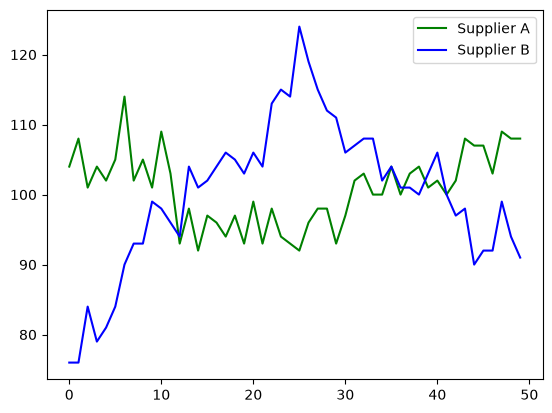

In [25]:
# 创建画布
fig = plt.figure()

# 创建 1 行 1 列的子图，并获取坐标轴对象 ax
ax = fig.add_subplot(1, 1, 1)

# 绘制供应商 A 的价格曲线：绿色实线，图例标签为 "Supplier A"
plt.plot(prices_A, 'g', label="Supplier A")

# 绘制供应商 B 的价格曲线：蓝色实线，图例标签为 "Supplier B"
plt.plot(prices_B, 'b', label="Supplier B")

# 显示图例（根据 label 自动生成）
plt.legend()

# 展示图像
plt.show()

从图上看，A 波动小、B 波动大，且两者不同步。这正是「组合优化」有意义的前提

| 观察 | 含义 |
|---|---|
| A 波动小 | A 是「稳健资产」 |
| B 波动大 | B 是「高风险资产」 |
| A 和 B 不完全同步 | 组合能降低风险 |
| 存在交叉点 | 不同时期优劣不同 |

Based on the historical data, can you tell which supplier it will be more profitable to work with? As discussed in the section [1.3](#1.3), you need to find such an $\omega \in \left[0, 1\right]$ which will minimize function $(2)$.

<a name='2.3'></a>

### 2.3 - Construct the Function $\mathcal{L}$ to Optimize and Find its Minimum Point

<a name='ex02'></a>

### Exercise 2

Calculate `f_of_omega`, corresponding to the $f^i\left(\omega\right)=p_A^i \omega+ p_B^i \left(1 - \omega\right)$. Prices $\{p_A^1, \cdots, p_A^k\}$ and $\{p_B^1, \cdots, p_B^k\}$ are saved in the arrays `prices_A` and `prices_B`. Thus, multiplying them by the scalars `omega` and `1 - omega` and adding together the resulting arrays, you will get an array containing $\{f^1\left(\omega\right), \cdots, f^k\left(\omega\right)\}$.


Then array `f_of_omega` can be taken to calculate `L_of_omega`, according to the expression $(2)$:

$$\mathcal{L}\left(\omega\right) = \frac{1}{k}\sum_{i=1}^{k}\left(f^i \left(\omega\right) -  \overline{f\left (\omega\right)}\right)^2$$

In [32]:
import numpy
def f_of_omega(omega):
    """
     计算「按比例 omega 从供应商 A 采购、其余从供应商 B 采购」时，
     每个月的单位成本数组。
     f^i(omega) = p_A^i * omega + p_B^i * (1 - omega)
     返回:
        长度为月份数的数组，
        每个元素是当月按比例 omega 采购时的单位成本。
    """
    ### START CODE HERE ### (~ 1 line of code)
    f = prices_A * omega + prices_B * (1 - omega)
    ### END CODE HERE ###
    return f

def L_of_omega(omega):
    """
    计算「按比例 omega 采购」时，月度成本的方差。

    说明:
        这个函数不是传统意义上的「预测损失函数」。
        它衡量的不是「预测值与真实值的误差」，而是「每个月成本
        与平均成本的偏离程度」，也就是方差。

        目标是最小化这个方差，让月度成本尽可能稳定（不要忽高忽低）。

    参数:
        omega (float): 从供应商 A 采购的比例，范围 [0, 1]。

    返回:
        L (float): 月度成本的方差。值越小，表示成本波动越小、越稳定。
    """
    f_values = f_of_omega(omega)
    f_mean = np.mean(f_values)
    L = 1 / len(f_values) * (np.sum((f_values - f_mean)**2))
    return L
    

In [30]:
print("L(omega = 0) =",L_of_omega(0))
print("L(omega = 0.2) =",L_of_omega(0.2))
print("L(omega = 0.8) =",L_of_omega(0.8))
print("L(omega = 1) =",L_of_omega(1))

L(omega = 0) = 110.72
L(omega = 0.2) = 61.156796
L(omega = 0.8) = 11.212797
L(omega = 1) = 27.48


##### __Expected Output__ 

```Python
L(omega = 0) = 110.72
L(omega = 0.2) = 61.1568
L(omega = 0.8) = 11.212797
L(omega = 1) = 27.48
```

In [31]:
w1_unittest.test_f_of_omega(f_of_omega)

 All tests passed


Analysing the output above, you can notice that values of the function $\mathcal{L}$ are decreasing for $\omega$ increasing from $0$ to $0.2$, then to $0.8$, but there is an increase of the function $\mathcal{L}$ when $\omega = 1$. What will be the $\omega$ giving the minimum value of the function $\mathcal{L}$?

In this simple example $\mathcal{L}\left(\omega\right)$ is a function of one variable and the problem of finding its minimum point with a certain accuracy is a trivial task. You just need to calculate function values for each $\omega = 0, 0.001, 0.002, \cdots , 1$ and find minimum element of the resulting array.

在这个简单例子里，$\mathcal{L}(\omega)$ 是单变量函数，以一定精度找它的最小值点，是一件平凡（简单）的事。一种「暴力求解」的思路
- trivial /ˈtrɪviəl/：平凡的、简单的、不费力的

Function `L_of_omega` will not work if you will pass an array instead of a single value of `omega` (it was not designed for that). It is possible to rewrite it in a way that it would be possible, but here there is no need in that right now - you can calculate the resulting values in the loop as there will be not as many of them.

不是所有代码都需要写成「向量化」的。

| 情况 | 建议 |
|---|---|
| 计算量小（几百到几千次） | 循环够了 |
| 计算量大（百万次以上） | 需要向量化 |
| 数据量大（百万行以上） | 需要向量化 |

<a name='ex03'></a>
### Exercise 3

Evaluate function `L_of_omega` for each of the elements of the array `omega_array` and pass the result into the corresponding element of the array `L_array` with the function `.at[<index>].set(<value>)`.

*Note*: `jax.numpy` has been uploaded instead of the original `NumPy`. Up to this moment `jax` functionality has not been actually used, but it will be called in the cells below. Thus there was no need to upload both versions of the package, and you have to use `.at[<index>].set(<value>)` function to update the array.

In [61]:
# Parameter endpoint=True will allow ending point 1 to be included in the array.
# This is why it is better to take N = 1001, not N = 1000
N = 1001
omega_array = np.linspace(0, 1, N, endpoint=True)

# This is organised as a function only for grading purposes.
def L_of_omega_array(omega_array):
    N = len(omega_array)
    L_array = np.zeros(N)
    for i in range(0,N):
        ### START CODE HERE ### (~ 2 lines of code)
        L = L_of_omega(omega_array[i])
        L_array = L_array.at[i].set(L)
        ### END CODE HERE ###
        
    return L_array

L_array = L_of_omega_array(omega_array)

In [62]:
print("L(omega = 0) =",L_array[0])
print("L(omega = 1) =",L_array[N-1])

L(omega = 0) = 110.72
L(omega = 1) = 27.48


##### __Expected Output__ 

```Python
L(omega = 0) = 110.72
L(omega = 1) = 27.48
```

In [63]:
w1_unittest.test_L_of_omega_array(L_of_omega_array)

 All tests passed


Now a minimum point of the function $\mathcal{L}\left(\omega\right)$ can be found with a `NumPy` function `argmin()`. As there were $N = 1001$ points taken in the segment $\left[0, 1\right]$, the result will be accurate to three decimal places:

In [64]:
i_opt = L_array.argmin()
omega_opt = omega_array[i_opt]
L_opt = L_array[i_opt]
print(f'omega_min = {omega_opt:.3f}\nL_of_omega_min = {L_opt:.7f}')

omega_min = 0.702
L_of_omega_min = 9.2497196


This result means that, based on the historical data, $\omega = 0.702$ is expected to be the most profitable choice for the share between suppliers A and B. It is reasonable to plan $70.2\%$ of product P to be supplied from Company A, and $29.8\%$ from Company B. 

If you would like to improve the accuracy, you just need to increase the number of points N. This is a very simple example of a model with one parameter, resulting in optimization of a function of one variable. It is computationally cheap to evaluate it in many points to find the minimum with certain accuracy. But in machine learning the models have hundreds of parameters, using similar approach you would need to perform millions of target function evaluations. This is not possible in most of the cases, and that's where Calculus with its methods and approaches comes into play. 

In the next weeks of this Course you will learn how to optimize multivariate functions using differentiation. But for now as you are on the learning curve, let's evaluate the derivative of the function $\mathcal{L}\left(\omega\right)$ at the points saved in the array `omega_array` to check that at the minimum point the derivative is actually the closest to zero. 

<a name='ex04'></a>
### Exercise 4

For each $\omega$ in the `omega_array` calculate $\frac{d\mathcal{L}}{d\omega}$ using `grad()` function from `JAX` library. Remember that you need to pass the function which you want to differentiate (here $\mathcal{L}\left(\omega\right)$) as an argument of `grad()` function and then evaluate the derivative for the corresponding element of the `omega_array`. Then pass the result into the corresponding element of the array `dLdOmega_array` with the function `.at[<index>].set(<value>)`.

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hint</b></font>
</summary>
<p>
<ul>
    <li>Function $\mathcal{L}\left(\omega\right)$ is implemented in the code as `L_of_omega`.</li>
</ul>
</p>

In [65]:
# This is organised as a function only for grading purposes.
def dLdOmega_of_omega_array(omega_array):
    N = len(omega_array)
    dLdOmega_array = np.zeros(N)

    for i in range(N):
        ### START CODE HERE ### (~ 2 lines of code)
        dLdOmega = grad(L_of_omega)(omega_array[i])
        dLdOmega_array = dLdOmega_array.at[i].set(dLdOmega)
        ### END CODE HERE ###
        
    return dLdOmega_array

dLdOmega_array = dLdOmega_of_omega_array(omega_array)

In [66]:
print("dLdOmega(omega = 0) =",dLdOmega_array[0])
print("dLdOmega(omega = 1) =",dLdOmega_array[N-1])

dLdOmega(omega = 0) = -288.96
dLdOmega(omega = 1) = 122.47999


##### __Expected Output__ 

```Python
dLdOmega(omega = 0) = -288.96
dLdOmega(omega = 1) = 122.47999
```

In [67]:
w1_unittest.test_dLdOmega_of_omega_array(dLdOmega_of_omega_array)

 All tests passed


Now to find the closest value of the derivative to $0$, take absolute values $\left|\frac{d\mathcal{L}}{d\omega}\right|$ for each omega and find minimum of them.

In [68]:
i_opt_2 = np.abs(dLdOmega_array).argmin()
omega_opt_2 = omega_array[i_opt_2]
dLdOmega_opt_2 = dLdOmega_array[i_opt_2]
print(f'omega_min = {omega_opt_2:.3f}\ndLdOmega_min = {dLdOmega_opt_2:.7f}')

omega_min = 0.702
dLdOmega_min = -0.1290760


The result is the same: $\omega = 0.702$. Let's plot $\mathcal{L}\left(\omega\right)$ and $\frac{d\mathcal{L}}{d\omega}$ to visualize the graphs of them, minimum point of the function $\mathcal{L}\left(\omega\right)$ and the point where its derivative is around $0$:

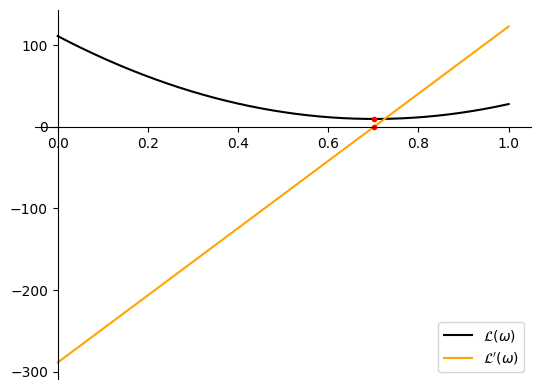

In [69]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
# Setting the axes at the origin.
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

plt.plot(omega_array,  L_array, "black", label = "$\mathcal{L}\\left(\omega\\right)$")
plt.plot(omega_array,  dLdOmega_array, "orange", label = "$\mathcal{L}\'\\left(\omega\\right)$")
plt.plot([omega_opt, omega_opt_2], [L_opt,dLdOmega_opt_2], 'ro', markersize=3)

plt.legend()

plt.show()

Congratulations, you have finished the assignment for this week! This example illustrates how optimization problems may appear in real life, and gives you an opportunity to explore the simple case of minimizing a function with one variable. Now it is time to learn about optimization of multivariate functions!